# RQ1: Is higher adoption of aggregated security practices associated with measurable improvements in security outcomes? 



Note:  Portions of this notebook were assisted with Claude.   An initial analysis was performed forming variables, creating models and initial analysis.   Claude assisted with PSM and adding comments.

## Imports

In [253]:
import math
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from stargazer.stargazer import Stargazer
from matplotlib import pyplot as plt

from settings import load_settings
from capstone import construct_final_dataset as fd

## Constants

In [254]:
SETTINGS = load_settings()

In [255]:
CONTROL_COLUMNS = [
    fd.C_REPOSITORY_CONTRIBUTIONS_COUNT,
    fd.C_REPOSITORY_SIZE_IN_KB,
    fd.C_REPOSITORY_AGE_IN_YEARS,
    fd.C_REPOSITORY_COMMIT_STALENESS_IN_DAYS,
    fd.C_PACKAGE_DEPENDENCY_COUNT,
    fd.C_PACKAGE_TOTAL_DOWNLOADS,
]

TARGET_COLUMNS = [
    fd.T_VULNERABILITY_COUNT,
    fd.T_MTTU,
    fd.T_MTTR,
]

C_LOG_REPOSITORY_CONTRIBUTIONS_COUNT = f"log_{fd.C_REPOSITORY_CONTRIBUTIONS_COUNT}"
C_LOG_REPOSITORY_SIZE_IN_KB = f"log_{fd.C_REPOSITORY_SIZE_IN_KB}"
C_LOG_REPOSITORY_AGE_IN_YEARS = f"log_{fd.C_REPOSITORY_AGE_IN_YEARS}"
C_LOG_REPOSITORY_COMMIT_STALENESS_IN_DAYS = f"log_{fd.C_REPOSITORY_COMMIT_STALENESS_IN_DAYS}"
C_LOG_PACKAGE_DEPENDENCY_COUNT = f"log_{fd.C_PACKAGE_DEPENDENCY_COUNT}"
C_LOG_PACKAGE_TOTAL_DOWNLOADS = f"log_{fd.C_PACKAGE_TOTAL_DOWNLOADS}"

T_LOG_MTTU = f"log_{fd.T_MTTU}"
T_LOG_MTTR = f"log_{fd.T_MTTR}"


LOG_CONTROL_COLUMNS = [
    C_LOG_REPOSITORY_CONTRIBUTIONS_COUNT,
    C_LOG_REPOSITORY_SIZE_IN_KB,
    C_LOG_REPOSITORY_AGE_IN_YEARS,
    C_LOG_REPOSITORY_COMMIT_STALENESS_IN_DAYS,
    C_LOG_PACKAGE_DEPENDENCY_COUNT,
    C_LOG_PACKAGE_TOTAL_DOWNLOADS,
]

## Loading Data

In [256]:
raw_df = pl.read_parquet(SETTINGS.research_question_1_dataset_path)

In [257]:
raw_df.head()

package_name,github_repo,package_dependency_count,package_total_downloads,github_repo_age_in_years,github_repo_commit_staleness_in_days,github_repo_contributions_count,github_repo_size_in_kb,aggregated_score,vul_count,mttr,mttu
str,str,u32,i64,f64,i64,i64,i64,f64,i64,f64,f64
"""h5xplorer""","""deeprank/h5xplorer""",5,2602,7.95,559,2,88127,2.9,0,null,null
"""pylabeladjust""","""mnoichl/pylabeladjust""",4,164300,1.93,688,1,101047,0.4,11,null,null
"""pyms-nist-search""","""domdfcoding/pynist""",8,165715,6.0,1,3,25599,null,null,0.0,3.219845
"""sql-manager""","""suqingdong/sql_manager""",3,29608,4.88,1491,1,5851,2.3,0,null,null
"""celerite2""","""exoplanet-dev/celerite2""",1,166896,7.16,0,7,2447,4.9,0,null,null


In [258]:
raw_df.describe()

statistic,package_name,github_repo,package_dependency_count,package_total_downloads,github_repo_age_in_years,github_repo_commit_staleness_in_days,github_repo_contributions_count,github_repo_size_in_kb,aggregated_score,vul_count,mttr,mttu
str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""46779""","""46779""",46779.0,46779.0,43086.0,43086.0,43151.0,43151.0,37422.0,37422.0,25262.0,25262.0
"""null_count""","""0""","""0""",0.0,0.0,3693.0,3693.0,3628.0,3628.0,9357.0,9357.0,21517.0,21517.0
"""mean""",null,null,5.620984,9.0404e6,5.512659,463.704336,12.472179,24371.912146,3.605903,5.830447,0.241445,5.203273
"""std""",null,null,7.413889,1.2423e8,3.450617,651.327571,31.736913,177510.051086,1.203484,22.338919,4.072507,16.031416
"""min""","""10xscale-agentflow""","""/edikedik""",0.0,5.0,0.01,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""25%""",null,null,2.0,6477.0,2.77,17.0,1.0,139.0,2.7,0.0,0.0,0.0
"""50%""",null,null,3.0,24113.0,5.12,154.0,4.0,701.0,3.4,0.0,0.0,0.595051
"""75%""",null,null,7.0,152344.0,7.69,678.0,11.0,5681.0,4.3,3.0,0.0,4.358773
"""max""","""zyte-parsers""","""~gb119/stoner-pythoncode""",268.0,9.4962e9,17.86,5005.0,472.0,1.0404261e7,11.5,694.0,217.992199,532.619235


### Effective Sample Size: Initial Dataset

The reference paper (Zahan et al.) reports the following dataset construction pipeline:
- **2,119,044** unique npm packages (Deps.dev BigQuery)
- **1,241,732** after requiring valid GitHub repositories
- **264,413** after requiring ≥1 dependency and ≥1 dependent
- **172,999** unique repositories (deduplicated)
- **145,817** with Scorecard scores (final analytic dataset)
- **22,412** with MTTR data available (15% of the above)

We compare our loaded dataset against these reference counts below.

In [259]:
PAPER_N_SCORECARD = 145_817
PAPER_N_MTTR = 22_412

n_initial = len(raw_df)
n_initial_non_null_mttr = raw_df.drop_nulls(subset=[fd.T_MTTR]).filter(pl.col(fd.T_MTTR) > 0).height
n_initial_non_null_mttu = raw_df.drop_nulls(subset=[fd.T_MTTU]).filter(pl.col(fd.T_MTTU) > 0).height

print("=" * 60)
print("STAGE 1 — Initial Dataset (raw_df)")
print("=" * 60)
print(f"  Rows loaded:                 {n_initial:>8,}")
print(f"  Paper reference (Scorecard): {PAPER_N_SCORECARD:>8,}")
print(f"  Ratio to paper:              {n_initial / PAPER_N_SCORECARD:>8.1%}")
print()
print(f"  Rows with MTTR > 0:          {n_initial_non_null_mttr:>8,}")
print(f"  Paper reference (MTTR):      {PAPER_N_MTTR:>8,}")
print(f"  Rows with MTTU > 0:          {n_initial_non_null_mttu:>8,}")

STAGE 1 — Initial Dataset (raw_df)
  Rows loaded:                   46,779
  Paper reference (Scorecard):  145,817
  Ratio to paper:                 32.1%

  Rows with MTTR > 0:             1,332
  Paper reference (MTTR):        22,412
  Rows with MTTU > 0:            15,531


## Inspecting Data

In [260]:
def plot_distributions(data: pd.DataFrame, columns: list[str]) -> None:
    ncols = math.ceil(len(columns) ** 0.5)
    nrows = math.ceil(len(columns) / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(10, 8))
    axes = axes.flatten()

    for i, col in enumerate(columns):
        sns.histplot(data[col].dropna(), kde=True, ax=axes[i])
        axes[i].set_title(col)

    # remove empty plots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

### Control Variables Distributions

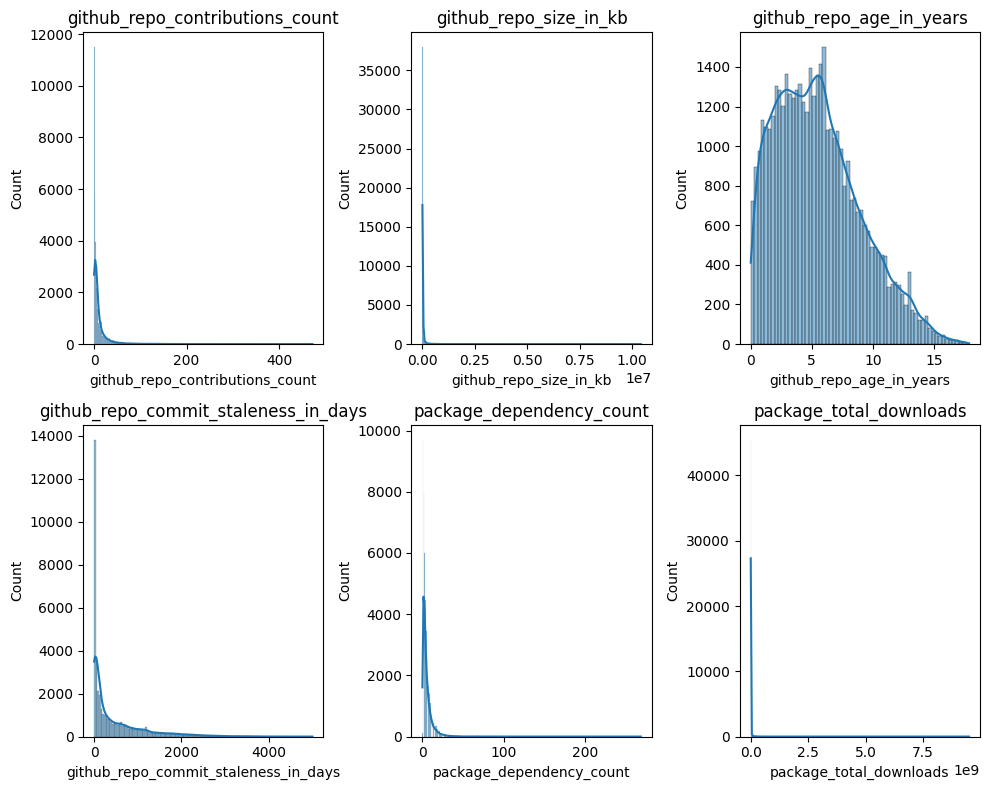

In [261]:
plot_distributions(raw_df.to_pandas(), CONTROL_COLUMNS)

### Target Variables Distributions

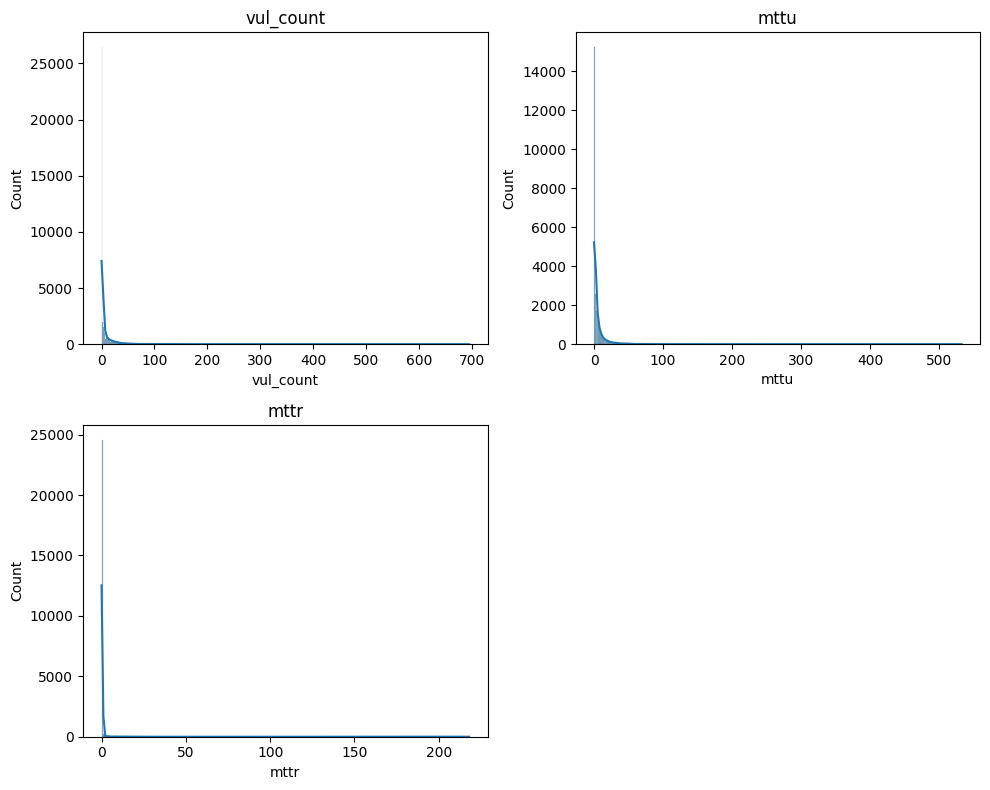

In [262]:
plot_distributions(raw_df.to_pandas(), TARGET_COLUMNS)

In [263]:
for col in [fd.T_MTTR, fd.T_MTTU]:
    s = raw_df.to_pandas()[col]
    print(col)
    print("min:", s.min())
    print("zeros:", (s == 0).sum())
    print("nulls:", s.isna().sum())
    print()

mttr
min: 0.0
zeros: 23930
nulls: 21517

mttu
min: 0.0
zeros: 9731
nulls: 21517



In [264]:
raw_df.select(TARGET_COLUMNS).describe()

statistic,vul_count,mttu,mttr
str,f64,f64,f64
"""count""",37422.0,25262.0,25262.0
"""null_count""",9357.0,21517.0,21517.0
"""mean""",5.830447,5.203273,0.241445
"""std""",22.338919,16.031416,4.072507
"""min""",0.0,0.0,0.0
"""25%""",0.0,0.0,0.0
"""50%""",0.0,0.595051,0.0
"""75%""",3.0,4.358773,0.0
"""max""",694.0,532.619235,217.992199


## Transforming Data

In [265]:
df = (
    raw_df
        .drop_nulls()
        .drop_nans()
        .to_pandas()
)

df[C_LOG_REPOSITORY_CONTRIBUTIONS_COUNT] = np.log1p(df[fd.C_REPOSITORY_CONTRIBUTIONS_COUNT])
df[C_LOG_REPOSITORY_SIZE_IN_KB] = np.log1p(df[fd.C_REPOSITORY_SIZE_IN_KB])
df[C_LOG_REPOSITORY_AGE_IN_YEARS] = np.log1p(df[fd.C_REPOSITORY_AGE_IN_YEARS])
df[C_LOG_REPOSITORY_COMMIT_STALENESS_IN_DAYS] = np.log1p(df[fd.C_REPOSITORY_COMMIT_STALENESS_IN_DAYS])
df[C_LOG_PACKAGE_DEPENDENCY_COUNT] = np.log1p(df[fd.C_PACKAGE_DEPENDENCY_COUNT])
df[C_LOG_PACKAGE_TOTAL_DOWNLOADS] = np.log1p(df[fd.C_PACKAGE_TOTAL_DOWNLOADS])

df[T_LOG_MTTR] = np.log1p(df[fd.T_MTTR])
df[T_LOG_MTTU] = np.log1p(df[fd.T_MTTU])

In [266]:
df.describe()

,package_dependency_count,package_total_downloads,github_repo_age_in_years,github_repo_commit_staleness_in_days,github_repo_contributions_count,github_repo_size_in_kb,aggregated_score,vul_count,mttr,mttu,log_github_repo_contributions_count,log_github_repo_size_in_kb,log_github_repo_age_in_years,log_github_repo_commit_staleness_in_days,log_package_dependency_count,log_package_total_downloads,log_mttr,log_mttu
count,19652.000000,1.965200e+04,19652.00000,19652.00000,19652.000000,1.965200e+04,19652.000000,19652.000000,19652.000000,19652.000000,19652.000000,19652.000000,19652.000000,19652.000000,19652.000000,19652.000000,19652.000000,19652.000000
mean,6.419296,1.787021e+07,5.92596,287.84368,16.806330,3.151563e+04,3.969983,5.908050,0.278263,5.438548,2.061639,7.328247,1.792931,4.030476,1.689867,11.657266,0.046307,0.951501
std,8.119211,1.813584e+08,3.46895,461.76806,38.211674,2.291052e+05,1.273253,22.444786,4.542228,16.890668,1.143480,2.391810,0.563975,2.272178,0.742168,2.678930,0.311273,1.146712
min,0.000000,6.540000e+02,0.07000,0.00000,0.000000,0.000000e+00,0.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.067659,0.000000,0.000000,6.484635,0.000000,0.000000
25%,2.000000,1.598550e+04,3.16000,10.00000,2.000000,2.390000e+02,3.100000,0.000000,0.000000,0.000000,1.098612,5.480639,1.425515,2.397895,1.098612,9.679500,0.000000,0.000000
50%,4.000000,6.291100e+04,5.57000,84.50000,6.000000,1.126000e+03,3.800000,0.000000,0.000000,0.567353,1.945910,7.027315,1.882514,4.448499,1.609438,11.049492,0.000000,0.449388
75%,8.000000,5.196192e+05,8.06000,378.00000,16.000000,7.814750e+03,4.800000,4.000000,0.000000,4.529343,2.833213,8.963896,2.203869,5.937536,2.197225,13.160853,0.000000,1.710069
max,268.000000,9.496153e+09,17.55000,4106.00000,470.000000,1.040426e+07,11.500000,694.000000,217.992199,532.619235,6.154858,16.157726,2.920470,8.320448,5.594711,22.974153,5.389036,6.279683


### Effective Sample Size: After Filtering

In [267]:
n_filtered = len(df)
n_dropped = n_initial - n_filtered
n_mttr_positive = (df[fd.T_MTTR] > 0).sum()
n_mttu_positive = (df[fd.T_MTTU] > 0).sum()

print("=" * 60)
print("STAGE 2 — After drop_nulls / drop_nans")
print("=" * 60)
print(f"  Rows retained:               {n_filtered:>8,}")
print(f"  Rows dropped (null/NaN):     {n_dropped:>8,}  ({n_dropped / n_initial:.1%} of initial)")
print()
print("  Per-target effective N (rows with outcome > 0):")
print(f"    Vul_Count (all rows):      {n_filtered:>8,}")
print(f"    MTTR (> 0):                {n_mttr_positive:>8,}  ({n_mttr_positive / n_filtered:.1%} of filtered)")
print(f"    MTTU (> 0):                {n_mttu_positive:>8,}  ({n_mttu_positive / n_filtered:.1%} of filtered)")
print()
print("  Paper used 145,817 for Vul_Count/MTTU and 22,412 for MTTR.")

STAGE 2 — After drop_nulls / drop_nans
  Rows retained:                 19,652
  Rows dropped (null/NaN):       27,127  (58.0% of initial)

  Per-target effective N (rows with outcome > 0):
    Vul_Count (all rows):        19,652
    MTTR (> 0):                   1,021  (5.2% of filtered)
    MTTU (> 0):                  11,922  (60.7% of filtered)

  Paper used 145,817 for Vul_Count/MTTU and 22,412 for MTTR.


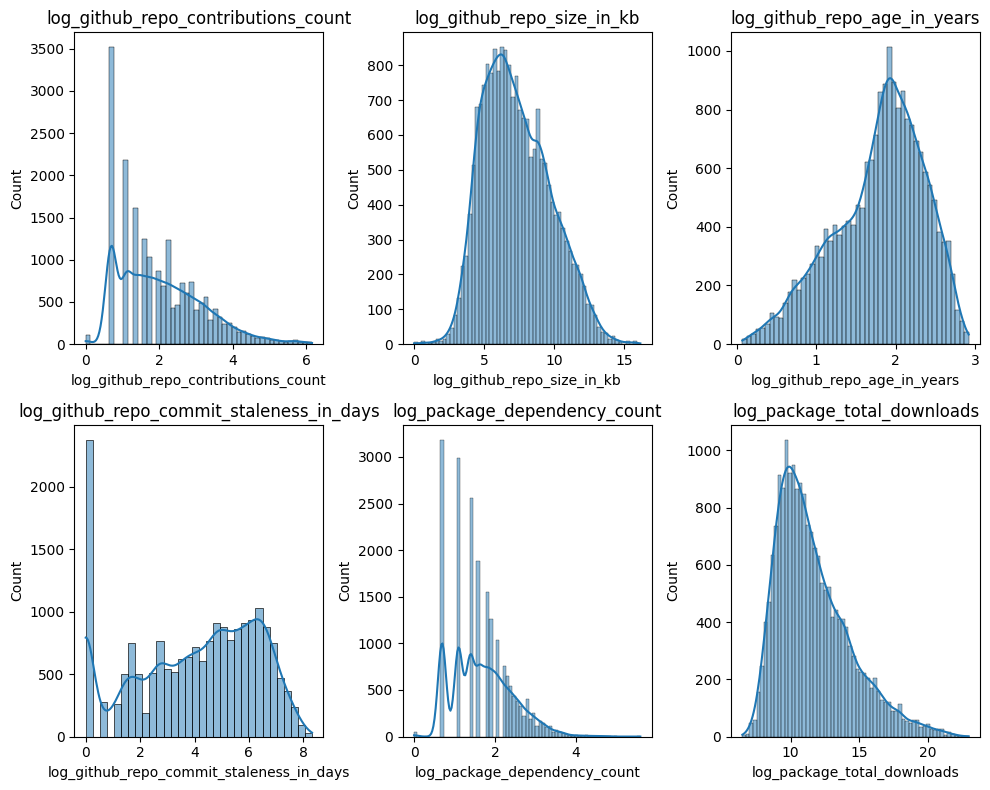

In [268]:
plot_distributions(df, LOG_CONTROL_COLUMNS)

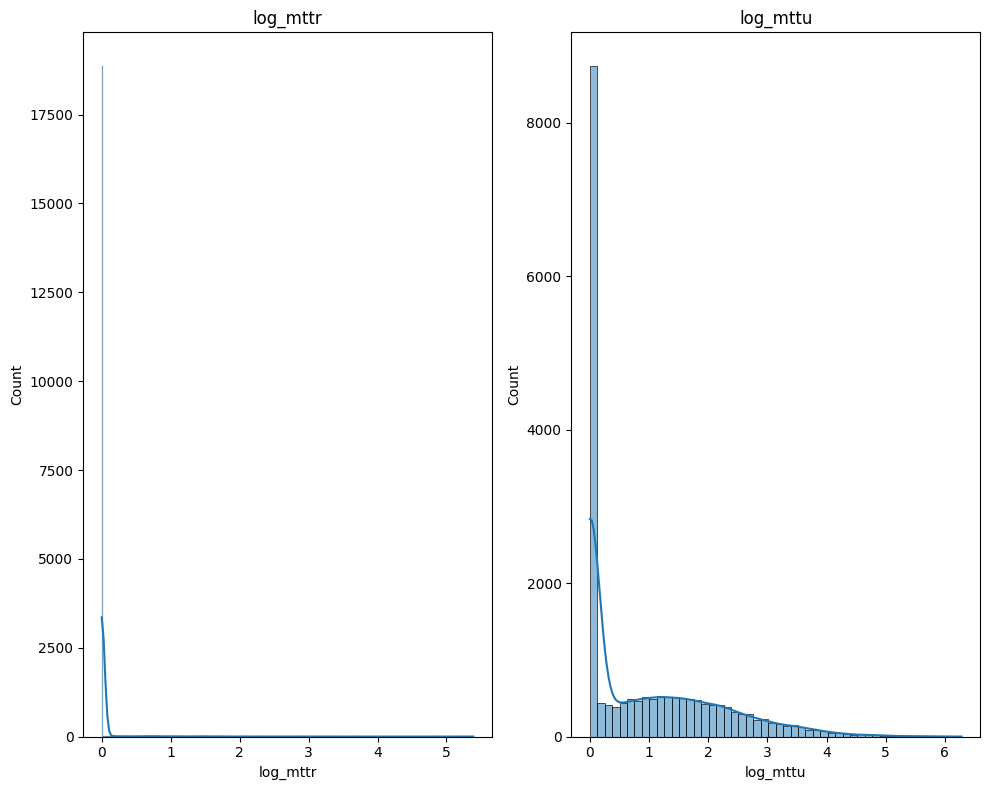

In [269]:
plot_distributions(df, [T_LOG_MTTR, T_LOG_MTTU])

## Modeling

We employ different modeling strategies tailored to the distributional properties of each outcome variable. For vulnerability counts, we begin with Poisson regression as a baseline but observe substantial overdispersion, with the variance exceeding the mean. To address this, we adopt Negative Binomial regression, which introduces a dispersion parameter to account for excess variability and provides a better fit for count data.

In contrast, mean time to recover (MTTR) and mean time to update (MTTU) are continuous, strictly positive duration variables rather than counts. Therefore, count-based models are not appropriate. Instead, we model these outcomes using generalized linear models with a Gamma distribution and log link, which are well-suited for right-skewed, positive data. As a baseline specification, we also estimate log-transformed ordinary least squares (OLS) models to ensure robustness and facilitate interpretation.

For all models, we log-transform highly skewed control variables (e.g., repository size, dependency count, and downloads) to reduce skewness and improve numerical stability. Coefficients from both Negative Binomial and Gamma models are interpreted as multiplicative effects, allowing us to express results in terms of percentage changes in the expected outcome.

In [270]:
df.columns

Index(['package_name', 'github_repo', 'package_dependency_count',
       'package_total_downloads', 'github_repo_age_in_years',
       'github_repo_commit_staleness_in_days',
       'github_repo_contributions_count', 'github_repo_size_in_kb',
       'aggregated_score', 'vul_count', 'mttr', 'mttu',
       'log_github_repo_contributions_count', 'log_github_repo_size_in_kb',
       'log_github_repo_age_in_years',
       'log_github_repo_commit_staleness_in_days',
       'log_package_dependency_count', 'log_package_total_downloads',
       'log_mttr', 'log_mttu'],
      dtype='object')

### Target: vul_count

#### Baseline: Poisson Regression

In [271]:
vul_count_formula = f"vul_count ~ aggregated_score + {' + '.join(LOG_CONTROL_COLUMNS)}"
vul_count_formula

'vul_count ~ aggregated_score + log_github_repo_contributions_count + log_github_repo_size_in_kb + log_github_repo_age_in_years + log_github_repo_commit_staleness_in_days + log_package_dependency_count + log_package_total_downloads'

In [272]:
vul_count_poisson_model = smf.glm(formula=vul_count_formula, data=df, family=sm.families.Poisson()).fit()

In [273]:
print(vul_count_poisson_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              vul_count   No. Observations:                19652
Model:                            GLM   Df Residuals:                    19644
Model Family:                 Poisson   Df Model:                            7
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.8193e+05
Date:                Sun, 12 Apr 2026   Deviance:                   3.3657e+05
Time:                        16:41:30   Pearson chi2:                 9.51e+05
No. Iterations:                     6   Pseudo R-squ. (CS):             0.9919
Covariance Type:            nonrobust                                         
                                               coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

In [274]:
dispersion = vul_count_poisson_model.pearson_chi2 / vul_count_poisson_model.df_resid
print(f"Dispersion: {dispersion}")
if dispersion > 1.5:
    print("Evidence of overdispersion detected.")

Dispersion: 48.43663597737468
Evidence of overdispersion detected.


#### Main: Negative Binomial Regression

In [275]:
def fit_vul_count_nb_model(data: pd.DataFrame, target_variable: str):
    X = data[["aggregated_score", *LOG_CONTROL_COLUMNS]]
    X = sm.add_constant(X)
    y = data[target_variable]
    poisson_res = sm.Poisson(y, X).fit(disp=0)
    start = np.append(poisson_res.params, 0.5)
    model = sm.NegativeBinomial(y, X).fit(start_params=start, method='nm', maxiter=2000)
    return model

In [276]:
vul_count_model = fit_vul_count_nb_model(df, fd.T_VULNERABILITY_COUNT)
print(vul_count_model.summary())

Optimization terminated successfully.
         Current function value: 1.910133
         Iterations: 895
         Function evaluations: 1321
                     NegativeBinomial Regression Results                      
Dep. Variable:              vul_count   No. Observations:                19652
Model:               NegativeBinomial   Df Residuals:                    19644
Method:                           MLE   Df Model:                            7
Date:                Sun, 12 Apr 2026   Pseudo R-squ.:                 0.02579
Time:                        16:41:31   Log-Likelihood:                -37538.
converged:                       True   LL-Null:                       -38532.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                               coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------
const    

### Target: MTTU

#### Baseline: OLS Regression

In [277]:
mttu_ols_formula = f"log_mttu ~ aggregated_score + {' + '.join(LOG_CONTROL_COLUMNS)}"
mttu_ols_formula

'log_mttu ~ aggregated_score + log_github_repo_contributions_count + log_github_repo_size_in_kb + log_github_repo_age_in_years + log_github_repo_commit_staleness_in_days + log_package_dependency_count + log_package_total_downloads'

In [278]:
mttu_ols_model = smf.ols(formula=mttu_ols_formula, data=df).fit()

print(mttu_ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:               log_mttu   R-squared:                       0.030
Model:                            OLS   Adj. R-squared:                  0.029
Method:                 Least Squares   F-statistic:                     86.00
Date:                Sun, 12 Apr 2026   Prob (F-statistic):          7.65e-124
Time:                        16:41:31   Log-Likelihood:                -30278.
No. Observations:               19652   AIC:                         6.057e+04
Df Residuals:                   19644   BIC:                         6.064e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                               coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

#### Main: Gamma GLM Regression

In [279]:
mttu_gamma_formula =  f"mttu ~ aggregated_score + {' + '.join(LOG_CONTROL_COLUMNS)}"

In [280]:
mttu_df = df.loc[df["mttu"] > 0].copy()
mttu_gamma_model = smf.glm(
    formula=mttu_gamma_formula,
    data=mttu_df,
    family=sm.families.Gamma(link=sm.families.links.log())
).fit()

print(mttu_gamma_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                   mttu   No. Observations:                11922
Model:                            GLM   Df Residuals:                    11914
Model Family:                   Gamma   Df Model:                            7
Link Function:                    log   Scale:                          3.8466
Method:                          IRLS   Log-Likelihood:                -35006.
Date:                Sun, 12 Apr 2026   Deviance:                       31939.
Time:                        16:41:31   Pearson chi2:                 4.58e+04
No. Iterations:                    19   Pseudo R-squ. (CS):            0.06179
Covariance Type:            nonrobust                                         
                                               coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

/venv/lib/python3.13/site-packages/statsmodels/genmod/families/links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(


In [281]:
# Lower AIC = better fit
print("OLS AIC:", mttu_ols_model.aic)
print("Gamma AIC:", mttu_gamma_model.aic)

OLS AIC: 60572.41647139208
Gamma AIC: 70028.6992889687


In [282]:
mttu_model = mttu_ols_model if mttu_ols_model.aic < mttu_gamma_model.aic else mttu_gamma_model

### Target: MTTR

#### Baseline: OLS Regression

In [283]:
mttr_ols_formula = f"log_mttr ~ aggregated_score + {' + '.join(LOG_CONTROL_COLUMNS)}"
mttr_ols_formula

'log_mttr ~ aggregated_score + log_github_repo_contributions_count + log_github_repo_size_in_kb + log_github_repo_age_in_years + log_github_repo_commit_staleness_in_days + log_package_dependency_count + log_package_total_downloads'

In [284]:
mttr_ols_model = smf.ols(formula=mttr_ols_formula, data=df).fit()
print(mttr_ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:               log_mttr   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     18.55
Date:                Sun, 12 Apr 2026   Prob (F-statistic):           8.24e-25
Time:                        16:41:32   Log-Likelihood:                -4884.2
No. Observations:               19652   AIC:                             9784.
Df Residuals:                   19644   BIC:                             9847.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                               coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

#### Main: Gamma GLM Regression

In [285]:
mttr_gamma_formula =  f"mttr ~ aggregated_score + {' + '.join(LOG_CONTROL_COLUMNS)}"
mttr_gamma_formula

'mttr ~ aggregated_score + log_github_repo_contributions_count + log_github_repo_size_in_kb + log_github_repo_age_in_years + log_github_repo_commit_staleness_in_days + log_package_dependency_count + log_package_total_downloads'

In [286]:
mttr_df = df.loc[df["mttr"] > 0].copy()

mttr_gamma_model = smf.glm(
    formula=mttr_gamma_formula,
    data=mttr_df,
    family=sm.families.Gamma(link=sm.families.links.log())
).fit()

print(mttr_gamma_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                   mttr   No. Observations:                 1021
Model:                            GLM   Df Residuals:                     1013
Model Family:                   Gamma   Df Model:                            7
Link Function:                    log   Scale:                          5.4459
Method:                          IRLS   Log-Likelihood:                -1011.4
Date:                Sun, 12 Apr 2026   Deviance:                       5598.0
Time:                        16:41:32   Pearson chi2:                 5.52e+03
No. Iterations:                    28   Pseudo R-squ. (CS):             0.1855
Covariance Type:            nonrobust                                         
                                               coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

/venv/lib/python3.13/site-packages/statsmodels/genmod/families/links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(


In [287]:
# Lower AIC = better fit
print("OLS AIC:", mttr_ols_model.aic)
print("Gamma AIC:", mttr_gamma_model.aic)

OLS AIC: 9784.325600929158
Gamma AIC: 2038.7724667366501


In [288]:
mttr_model = mttr_gamma_model

### Summary

In [289]:
stargazer = Stargazer([
    vul_count_model,
    mttr_model, 
    mttu_model,
])

stargazer.title("Regression Results")
stargazer.custom_columns(["Vul Count", "MTTR", "MTTU"], [1, 1, 1])
stargazer.show_confidence_intervals(True)

In [290]:
(np.exp(0.206) - 1) * 100

np.float64(22.875320399531198)

In [291]:
stargazer

## Propensity Score Matching (PSM)

Propensity Score Matching strengthens our causal argument by creating comparable treatment and control groups before estimating treatment effects. Rather than adjusting for confounders parametrically in regression, we first **match** repositories that look similar on observable characteristics but differ in their security practice adoption. Regressions on the matched sample are then less sensitive to model misspecification, providing a complementary ("doubly robust") identification strategy.

In [292]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors

### Step 1: Define Treatment Variable

PSM requires a binary treatment indicator. Following the reference paper, we dichotomize `aggregated_score` using the empirical top quartile as the treatment threshold. Repositories at or above this threshold are classified as "treated" (high security practice adoption).

In [293]:
print(df["aggregated_score"].describe())
print(f"\n75th percentile: {df['aggregated_score'].quantile(0.75):.2f}")

TREATMENT_THRESHOLD = df["aggregated_score"].quantile(0.75)
df["treated"] = (df["aggregated_score"] >= TREATMENT_THRESHOLD).astype(int)

print(f"\nTreatment threshold: {TREATMENT_THRESHOLD:.2f}")
print(f"Treated: {df['treated'].sum()}")
print(f"Control: {(df['treated'] == 0).sum()}")

count    19652.000000
mean         3.969983
std          1.273253
min          0.100000
25%          3.100000
50%          3.800000
75%          4.800000
max         11.500000
Name: aggregated_score, dtype: float64

75th percentile: 4.80

Treatment threshold: 4.80
Treated: 4968
Control: 14684


### Step 2: Estimate Propensity Scores

The propensity score is the predicted probability of being "treated" given the observed covariates. We estimate it via logistic regression on the same log-transformed control variables used in our main analysis. Substantial overlap between treated and control distributions is required for matching to be meaningful.

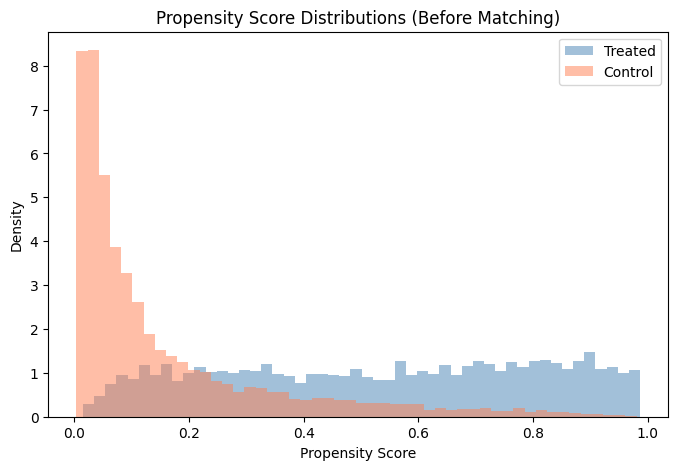

In [294]:
X_ps = df[LOG_CONTROL_COLUMNS]
y_ps = df["treated"]

ps_model = LogisticRegression(max_iter=1000, solver="lbfgs")
ps_model.fit(X_ps, y_ps)

df["propensity_score"] = ps_model.predict_proba(X_ps)[:, 1]

# Check overlap between treated and control propensity score distributions
fig, ax = plt.subplots(figsize=(8, 5))
for group, label, color in [(1, "Treated", "steelblue"), (0, "Control", "coral")]:
    ax.hist(df.loc[df["treated"] == group, "propensity_score"],
            bins=50, alpha=0.5, label=label, color=color, density=True)
ax.set_xlabel("Propensity Score")
ax.set_ylabel("Density")
ax.set_title("Propensity Score Distributions (Before Matching)")
ax.legend()
plt.show()

### Step 3: Nearest-Neighbor Matching

For each treated unit, we find the closest control unit by propensity score using nearest-neighbor matching. Matches are accepted only if the distance falls within a caliper of 0.1 standard deviations of the propensity score. Matching is performed without replacement (each control unit matches to at most one treated unit) and greedily by distance (best pairs first).

In [295]:
caliper = 0.1 * df["propensity_score"].std()

treated_idx = df.index[df["treated"] == 1].values
control_idx = df.index[df["treated"] == 0].values

treated_ps = df.loc[treated_idx, "propensity_score"].values.reshape(-1, 1)
control_ps = df.loc[control_idx, "propensity_score"].values.reshape(-1, 1)

nn = NearestNeighbors(n_neighbors=1, metric="euclidean")
nn.fit(control_ps)
distances, indices = nn.kneighbors(treated_ps)

# Match greedily, best pairs first
matched_treated, matched_control = [], []
used_control = set()

for i in np.argsort(distances.flatten()):
    if distances[i, 0] > caliper:
        continue
    ctrl_local = indices[i, 0]
    if ctrl_local in used_control:
        continue
    matched_treated.append(treated_idx[i])
    matched_control.append(control_idx[ctrl_local])
    used_control.add(ctrl_local)

matched_idx = np.array(matched_treated + matched_control)
matched_df = df.loc[matched_idx].copy()

print(f"Caliper: {caliper:.4f}")
print(f"Matched pairs: {len(matched_treated)}")
print(f"Unmatched treated: {df['treated'].sum() - len(matched_treated)}")
print(f"Match rate: {len(matched_treated) / df['treated'].sum():.1%}")

Caliper: 0.0268
Matched pairs: 2092
Unmatched treated: 2876
Match rate: 42.1%


### Effective Sample Size: After PSM Matching

The table below consolidates sample sizes at every pipeline stage so a reader
can assess where statistical power is gained or lost relative to the paper's
reported counts.

In [296]:
n_treated = df["treated"].sum()
n_control = (df["treated"] == 0).sum()
n_matched_pairs = len(matched_treated)
n_matched_total = len(matched_df)
n_matched_mttr = (matched_df[fd.T_MTTR] > 0).sum()
n_matched_mttu = (matched_df[fd.T_MTTU] > 0).sum()

print("=" * 60)
print("STAGE 3 — After PSM Matching")
print("=" * 60)
print(f"  Pre-match treated:           {n_treated:>8,}")
print(f"  Pre-match control:           {n_control:>8,}")
print(f"  Matched pairs:               {n_matched_pairs:>8,}")
print(f"  Matched total (2 × pairs):   {n_matched_total:>8,}")
print(f"  Unmatched treated:           {n_treated - n_matched_pairs:>8,}")
print(f"  Match rate:                  {n_matched_pairs / n_treated:>8.1%}")
print()
print("  Matched-sample effective N per target:")
print(f"    Vul_Count:                 {n_matched_total:>8,}")
print(f"    MTTR (> 0):                {n_matched_mttr:>8,}")
print(f"    MTTU (> 0):                {n_matched_mttu:>8,}")

# --- Consolidated pipeline summary table ---
print()
print("=" * 60)
print("CONSOLIDATED SAMPLE-SIZE PIPELINE")
print("=" * 60)

pipeline = pd.DataFrame([
    {"Stage": "1. Initial (loaded)",        "N": n_initial,         "Vul_Count": n_initial,   "MTTR (>0)": n_initial_non_null_mttr,  "MTTU (>0)": n_initial_non_null_mttu},
    {"Stage": "2. Filtered (no null/NaN)",  "N": n_filtered,        "Vul_Count": n_filtered,  "MTTR (>0)": n_mttr_positive,          "MTTU (>0)": n_mttu_positive},
    {"Stage": "3. PSM pre-match (treated)", "N": n_treated,         "Vul_Count": n_treated,   "MTTR (>0)": "—",                      "MTTU (>0)": "—"},
    {"Stage": "3. PSM pre-match (control)", "N": n_control,         "Vul_Count": n_control,   "MTTR (>0)": "—",                      "MTTU (>0)": "—"},
    {"Stage": "4. PSM matched",             "N": n_matched_total,   "Vul_Count": n_matched_total, "MTTR (>0)": n_matched_mttr,       "MTTU (>0)": n_matched_mttu},
    {"Stage": "— Paper: full sample",       "N": PAPER_N_SCORECARD, "Vul_Count": PAPER_N_SCORECARD, "MTTR (>0)": PAPER_N_MTTR,       "MTTU (>0)": "—"},
])
pipeline = pipeline.set_index("Stage")
pipeline

STAGE 3 — After PSM Matching
  Pre-match treated:              4,968
  Pre-match control:             14,684
  Matched pairs:                  2,092
  Matched total (2 × pairs):      4,184
  Unmatched treated:              2,876
  Match rate:                     42.1%

  Matched-sample effective N per target:
    Vul_Count:                    4,184
    MTTR (> 0):                     218
    MTTU (> 0):                   2,669

CONSOLIDATED SAMPLE-SIZE PIPELINE


,N,Vul_Count,MTTR (>0),MTTU (>0)
Stage,,,,
1. Initial (loaded),46779,46779,1332,15531
2. Filtered (no null/NaN),19652,19652,1021,11922
3. PSM pre-match (treated),4968,4968,—,—
3. PSM pre-match (control),14684,14684,—,—
4. PSM matched,4184,4184,218,2669
— Paper: full sample,145817,145817,22412,—


### Step 4: Covariate Balance Assessment

We assess matching quality using Standardized Mean Differences (SMD). After matching, all absolute SMDs should fall below 0.1 (below 0.05 is excellent; above 0.25 indicates a serious problem). The Love plot visualizes the improvement in balance.

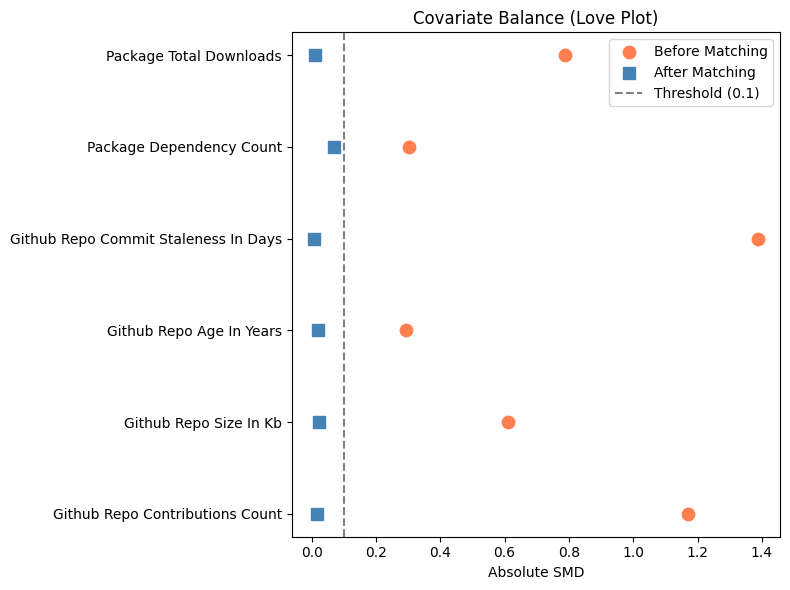

In [297]:
def compute_smd(data, covariates, treatment_col="treated"):
    treated = data[data[treatment_col] == 1]
    control = data[data[treatment_col] == 0]
    results = {}
    for cov in covariates:
        mean_diff = treated[cov].mean() - control[cov].mean()
        pooled_std = np.sqrt((treated[cov].var() + control[cov].var()) / 2)
        results[cov] = mean_diff / pooled_std if pooled_std > 0 else 0.0
    return results

smd_before = compute_smd(df, LOG_CONTROL_COLUMNS)
smd_after = compute_smd(matched_df, LOG_CONTROL_COLUMNS)

# Love plot
fig, ax = plt.subplots(figsize=(8, 6))
labels = [c.replace("log_", "").replace("_", " ").title() for c in LOG_CONTROL_COLUMNS]

ax.scatter([abs(v) for v in smd_before.values()], range(len(labels)),
           marker="o", color="coral", s=80, label="Before Matching")
ax.scatter([abs(v) for v in smd_after.values()], range(len(labels)),
           marker="s", color="steelblue", s=80, label="After Matching")
ax.axvline(0.1, color="gray", linestyle="--", label="Threshold (0.1)")
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.set_xlabel("Absolute SMD")
ax.set_title("Covariate Balance (Love Plot)")
ax.legend()
plt.tight_layout()
plt.show()

### Step 5: Regressions on Matched Sample

We re-estimate the same regression specifications from our main analysis on the matched sample. This "doubly robust" approach combines matching with parametric adjustment. Comparing full-sample and matched-sample coefficients is informative: if `aggregated_score`'s coefficient changes substantially, that suggests selection bias was present and matching is doing meaningful work.

In [298]:
# Target: vul_count
vul_count_model_matched = fit_vul_count_nb_model(matched_df, fd.T_VULNERABILITY_COUNT)
print(vul_count_model_matched.summary())

Optimization terminated successfully.
         Current function value: 1.817633
         Iterations: 1583
         Function evaluations: 2224
                     NegativeBinomial Regression Results                      
Dep. Variable:              vul_count   No. Observations:                 4184
Model:               NegativeBinomial   Df Residuals:                     4176
Method:                           MLE   Df Model:                            7
Date:                Sun, 12 Apr 2026   Pseudo R-squ.:                 0.02391
Time:                        16:41:33   Log-Likelihood:                -7605.0
converged:                       True   LL-Null:                       -7791.3
Covariance Type:            nonrobust   LLR p-value:                 1.750e-76
                                               coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------
const   

In [299]:
# Target: MTTU
mttu_matched_df = matched_df.loc[matched_df["mttu"] > 0].copy()

mttu_gamma_model_matched = smf.glm(
    formula=mttu_gamma_formula,
    data=mttu_matched_df,
    family=sm.families.Gamma(link=sm.families.links.log())
).fit()

print(mttu_gamma_model_matched.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                   mttu   No. Observations:                 2669
Model:                            GLM   Df Residuals:                     2661
Model Family:                   Gamma   Df Model:                            7
Link Function:                    log   Scale:                          3.8541
Method:                          IRLS   Log-Likelihood:                -7636.7
Date:                Sun, 12 Apr 2026   Deviance:                       7129.0
Time:                        16:41:33   Pearson chi2:                 1.03e+04
No. Iterations:                    18   Pseudo R-squ. (CS):            0.05743
Covariance Type:            nonrobust                                         
                                               coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

/venv/lib/python3.13/site-packages/statsmodels/genmod/families/links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(


In [300]:
# Target: MTTR
mttr_matched_df = matched_df.loc[matched_df["mttr"] > 0].copy()

mttr_gamma_model_matched = smf.glm(
    formula=mttr_gamma_formula,
    data=mttr_matched_df,
    family=sm.families.Gamma(link=sm.families.links.log())
).fit()

print(mttr_gamma_model_matched.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                   mttr   No. Observations:                  218
Model:                            GLM   Df Residuals:                      210
Model Family:                   Gamma   Df Model:                            7
Link Function:                    log   Scale:                          4.1586
Method:                          IRLS   Log-Likelihood:                -314.12
Date:                Sun, 12 Apr 2026   Deviance:                       991.88
Time:                        16:41:33   Pearson chi2:                     873.
No. Iterations:                    55   Pseudo R-squ. (CS):             0.2617
Covariance Type:            nonrobust                                         
                                               coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

/venv/lib/python3.13/site-packages/statsmodels/genmod/families/links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(


#### Summary

In [301]:
stargazer_matched = Stargazer([
    vul_count_model_matched,
    mttr_gamma_model_matched,
    mttu_gamma_model_matched,
])

stargazer_matched.title("Regression Results (Matched Sample)")
stargazer_matched.custom_columns(["Vul Count", "MTTR", "MTTU"], [1, 1, 1])
stargazer_matched.show_confidence_intervals(True)

In [302]:
stargazer_matched

### Step 6: Average Treatment Effect (ATE)

The ATE measures the mean difference in outcomes between matched treated and control groups. We use bootstrap resampling (2,000 iterations) to construct 95% confidence intervals. A negative ATE for vulnerability count means higher security practice adoption is associated with fewer vulnerabilities; a negative ATE for MTTR/MTTU means faster recovery/update times. If the CI includes zero, the effect is not statistically significant at the 5% level.

In [303]:
def compute_ate(data, outcome_col):
    return (data.loc[data["treated"] == 1, outcome_col].mean()
          - data.loc[data["treated"] == 0, outcome_col].mean())

def bootstrap_ate(data, outcome_col, n_bootstrap=2000, seed=42):
    rng = np.random.RandomState(seed)
    estimates = []
    for _ in range(n_bootstrap):
        boot = data.sample(n=len(data), replace=True, random_state=rng)
        estimates.append(compute_ate(boot, outcome_col))
    estimates = np.array(estimates)
    return {
        "ate": compute_ate(data, outcome_col),
        "ci_lower": np.percentile(estimates, 2.5),
        "ci_upper": np.percentile(estimates, 97.5),
        "distribution": estimates,
    }

outcomes = [("Vul Count", "vul_count"), ("MTTR", "mttr"), ("MTTU", "mttu")]

ate_results = {}
for name, col in outcomes:
    result = bootstrap_ate(matched_df.dropna(subset=[col]), col)
    ate_results[name] = result
    print(f"{name}: ATE = {result['ate']:.4f}, 95% CI = [{result['ci_lower']:.4f}, {result['ci_upper']:.4f}]")

Vul Count: ATE = -4.2323, 95% CI = [-5.1880, -3.3015]
MTTR: ATE = -0.0256, 95% CI = [-0.3865, 0.3157]
MTTU: ATE = -0.0627, 95% CI = [-1.1241, 1.0132]


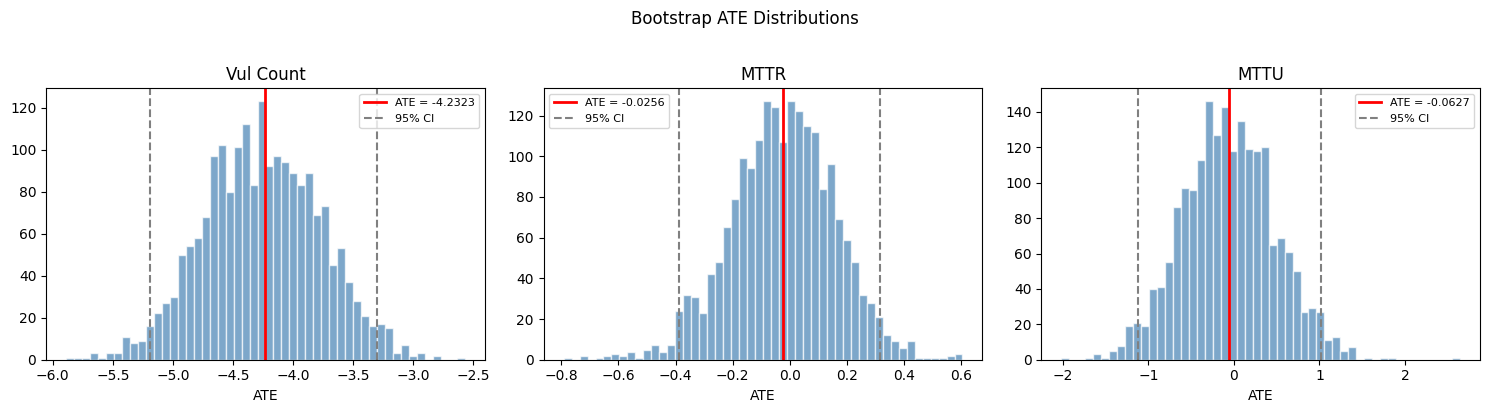

In [304]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, _) in zip(axes, outcomes):
    result = ate_results[name]
    ax.hist(result["distribution"], bins=50, color="steelblue", alpha=0.7, edgecolor="white")
    ax.axvline(result["ate"], color="red", linestyle="-", linewidth=2, label=f"ATE = {result['ate']:.4f}")
    ax.axvline(result["ci_lower"], color="gray", linestyle="--", label="95% CI")
    ax.axvline(result["ci_upper"], color="gray", linestyle="--")
    ax.set_title(name)
    ax.set_xlabel("ATE")
    ax.legend(fontsize=8)

plt.suptitle("Bootstrap ATE Distributions", y=1.02)
plt.tight_layout()
plt.show()

### Step 7: Heterogeneity Analysis

We stratify the matched sample by terciles of each control variable to examine whether the treatment effect varies across repository types (e.g., large vs. small repos, old vs. new). This analysis is exploratory — tercile-level ATEs have smaller sample sizes and wider confidence intervals.

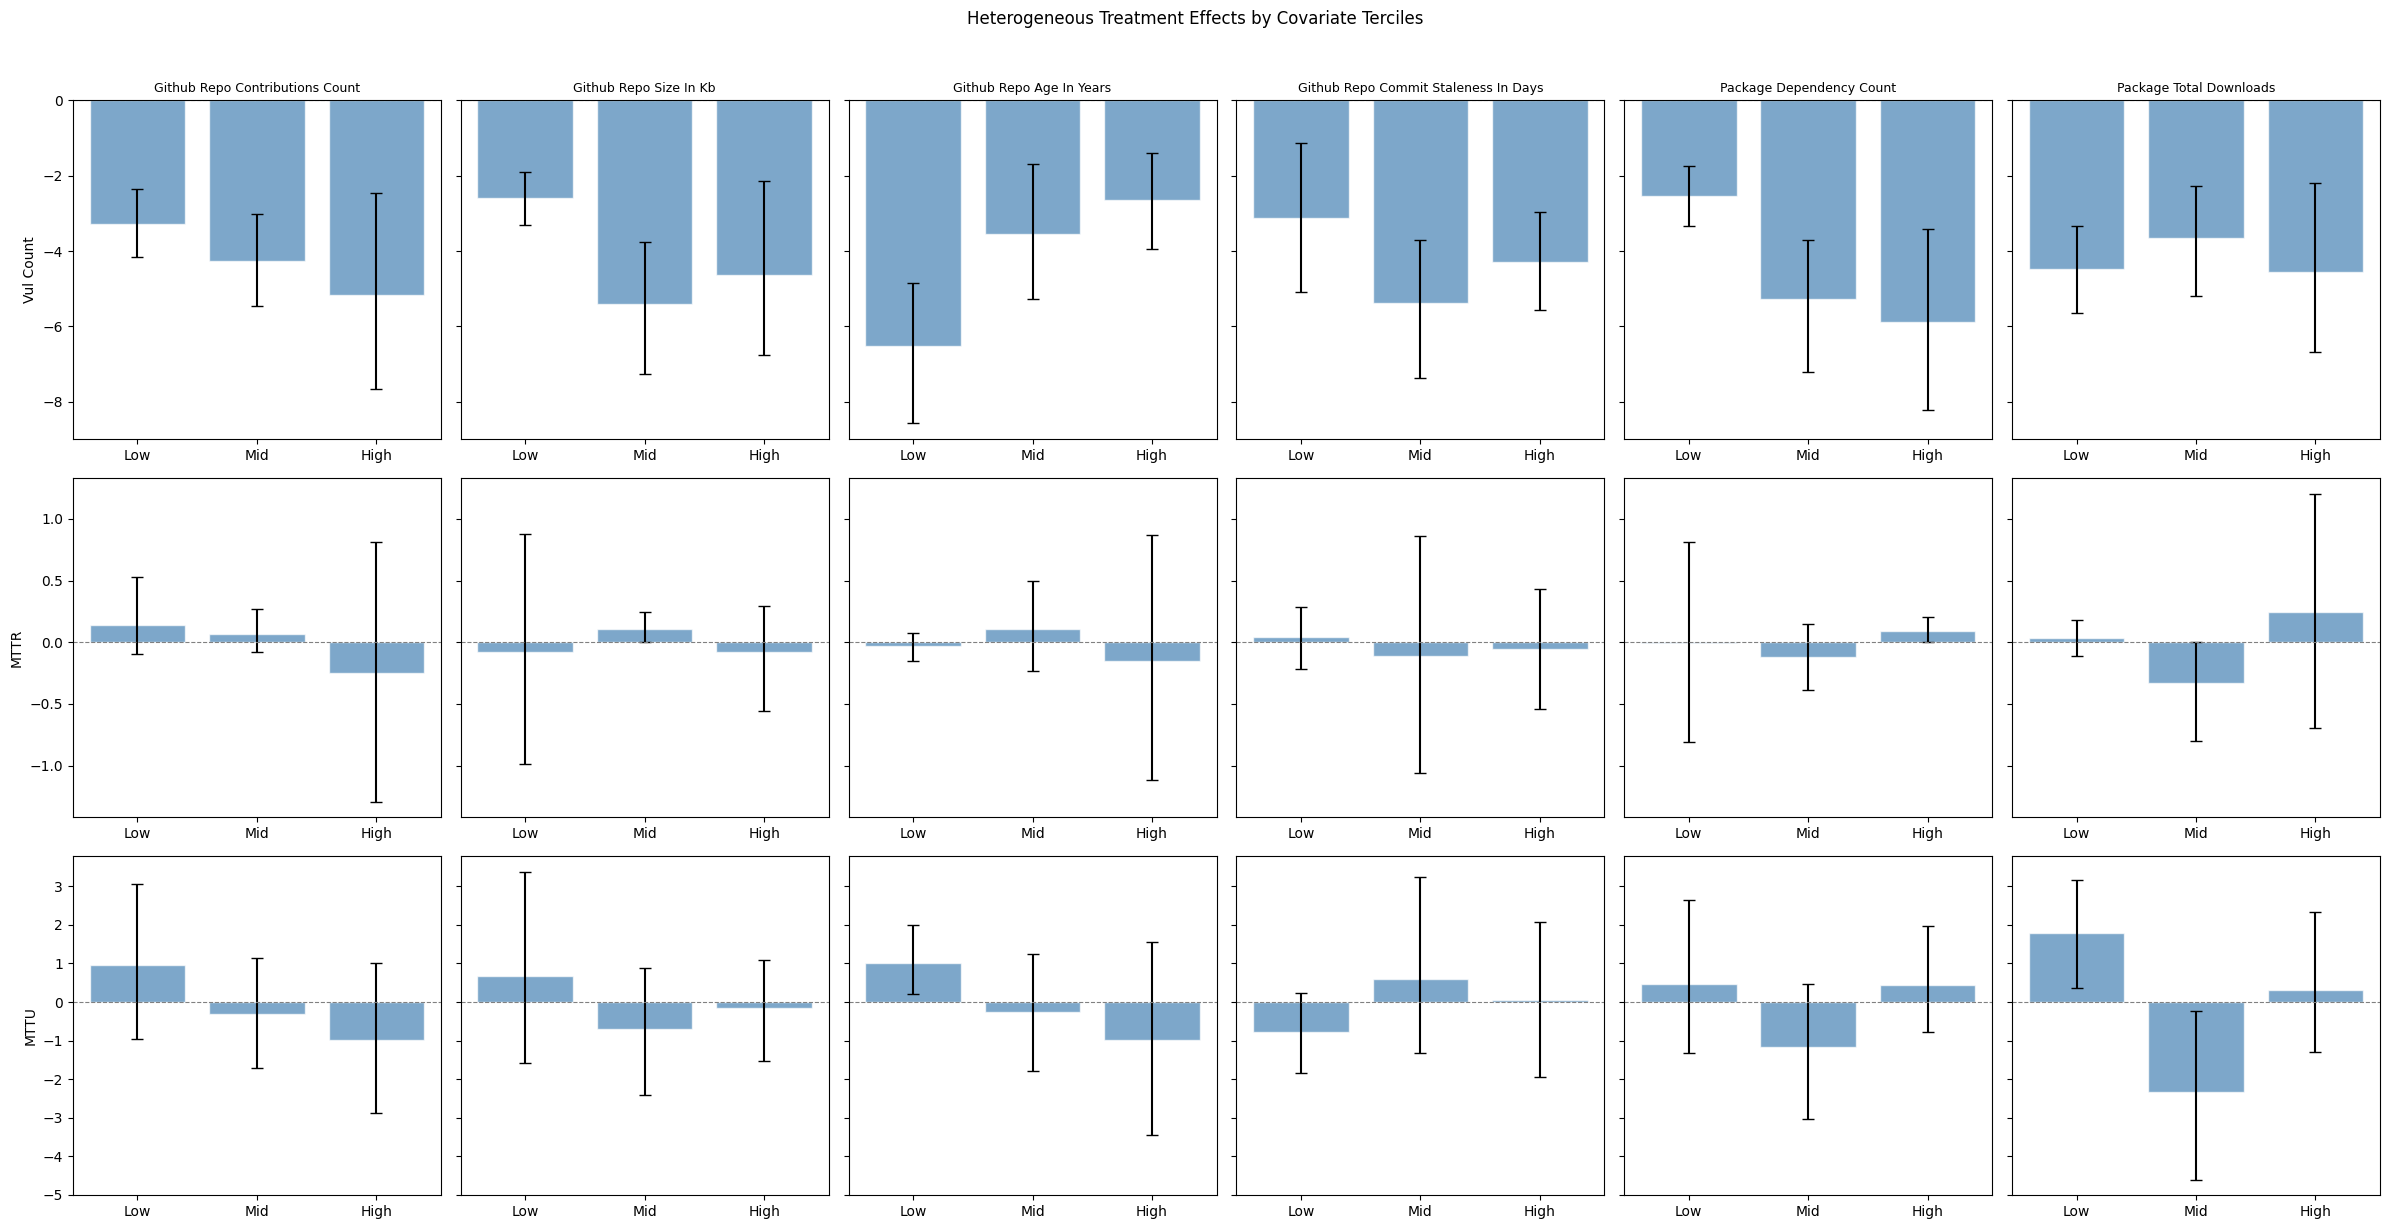

In [305]:
def tercile_ate(data, stratify_col, outcome_col):
    data = data.copy()
    data["tercile"] = pd.qcut(data[stratify_col], q=3, labels=["Low", "Mid", "High"])
    results = {}
    for label in ["Low", "Mid", "High"]:
        subset = data[data["tercile"] == label]
        if subset["treated"].nunique() < 2:
            results[label] = None
            continue
        results[label] = bootstrap_ate(subset, outcome_col, n_bootstrap=1000)
    return results

outcomes = [("Vul Count", "vul_count"), ("MTTR", "mttr"), ("MTTU", "mttu")]

fig, axes = plt.subplots(len(outcomes), len(LOG_CONTROL_COLUMNS), figsize=(24, 12), sharey="row")

for row, (outcome_name, outcome_col) in enumerate(outcomes):
    analysis_df = matched_df.dropna(subset=[outcome_col])
    for col_idx, strat_col in enumerate(LOG_CONTROL_COLUMNS):
        ax = axes[row, col_idx]
        results = tercile_ate(analysis_df, strat_col, outcome_col)

        tercile_labels, ates, ci_lowers, ci_uppers = [], [], [], []
        for label in ["Low", "Mid", "High"]:
            if results[label] is not None:
                tercile_labels.append(label)
                ates.append(results[label]["ate"])
                ci_lowers.append(results[label]["ci_lower"])
                ci_uppers.append(results[label]["ci_upper"])

        if ates:
            yerr_lower = [a - cl for a, cl in zip(ates, ci_lowers)]
            yerr_upper = [cu - a for a, cu in zip(ates, ci_uppers)]
            ax.bar(tercile_labels, ates, yerr=[yerr_lower, yerr_upper],
                   capsize=4, color="steelblue", alpha=0.7, edgecolor="white")
            ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)

        if row == 0:
            ax.set_title(strat_col.replace("log_", "").replace("_", " ").title(), fontsize=9)
        if col_idx == 0:
            ax.set_ylabel(outcome_name)

plt.suptitle("Heterogeneous Treatment Effects by Covariate Terciles", y=1.02)
plt.tight_layout()
plt.show()